<a href="https://colab.research.google.com/github/Deep7285/bayesian_surroage_gpr_fsw_properties_prediction/blob/main/FSW_GPR_DesignSpace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style='background:#1a2744; color:white; padding:28px 32px; border-radius:10px; margin-bottom:12px;'>
<h1 style='color:#f0c040; margin:0 0 6px 0;'>Physics-Informed Surrogate Modelling for Dissimilar FSW</h1>
<h3 style='color:#b0c8f0; margin:0 0 14px 0;'>Process–Structure–Property Design Space via Gaussian Process Regression</h3>
<p style='margin:0; font-size:15px;'>
</div>
---

>
> This notebook presents the **methodology and analytical framework** for an ongoing research project. All numerical demonstrations in this notebook use **representative FSW trials data to match the physical characteristics of the problem**.
>

## Table of Contents

1. [Background and Motivation](#section1)
2. [Physical properties correlation](#section2)
3. [Data Loading](#section3)
4. [Exploratory Data Analysis (EDA)](#section4)
5. [Physics-Informed Feature Engineering](#section5)
6. [Gaussian Process Regression (GPR) Modelling](#section6)
7. [Model Validation using the Leave One Out Cross Validation (LOOCV)](#section7)
8. [Process Design Space Characterisation](#section8)
9. [Bayesian Optimisation Analysis (BO)](#section9)
10. [PSP Chain Validation](#section10)
11. [Discussion and Next Steps](#section11)

<a id='section1'></a>
## 1. Background and Motivation

This works relates the friction stir welding (FSW) experimental investigation of dismmilar materials to physics informed mathematical modelling. The purpose to understand the relationship between process parameters and its outcomes such as IMCs and joint strength and whether this could be rationalised through a physical mechanism rather other then empirical observation.

The peocess and property correlation is well estabilished from literature: the thickness of IMCs layer formation at the Al–Steel interface during welding is the major structural factor controlling joint strength. Thinner IMC often leads to stronger joint. And IMC thickness is controlled by the thermal history of the weld, which is in turn governed by the tool rotation speed (ω) and traverse speed (v).

This established a complete **Process → Structure → Property (PSP) linkage** for the system. **Process parameters (rotation speed, traverse speed, plunge depth)** related by $${Q \propto \,\omega^2/v}$$ which responsible for IMCs thickness formation, grain size which emerge as **properties variations ( strength, hardness etc.)**

This analsyis explore the data-driven approach to:
- Map the **continuous process design space** with quantified uncertainty
- Encode the known physical mechanism as a *prior* into the model.
- Demonstrate that Bayesian Optimisation could have navigated the design space more efficiently than the experimental trial-and-error approach
- Connecting physical understanding to probabilistic modelling for limited experimental datasets, which is broadly applicable across materials processing problems.

<a id='section2'></a>
## 2. Physical properties correlation using PSP linkage

### 2.1 Heat Input as the governing Variable

The FSW heat input proxy, derived from the Arbegast–Hartley (1998) thermal model, relates peak temperature to process parameters:

$$\frac{T}{T_m} = C \left(\frac{\omega^2}{v \cdot 10^4}\right)^{\alpha}$$

where $T_m$ is the melting point of the softer material ( say Al), $C \in [0.65, 0.75]$, and $\alpha \in [0.04, 0.06]$ are empirical constants. This means heat input scales with $\omega^2/v$.

### 2.2 Why the Log Transform Is Physically Motivated

Intermetallic compound growth at the Al–Steel interface follows Arrhenius diffusion kinetics:

$$\delta_{\text{IMC}} \propto D_0 \exp\left(\frac{-E_a}{RT}\right) \cdot \sqrt{t}$$

Since $T$ scales with $\log(\omega^2/v)$ through the Arbegast–Hartley equation, and IMC thickness scales exponentially with $T$, the relationship between $\log(\omega^2/v)$ and UTS is approximately **linear in log-space**.

In [ ]:
# library and imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
from scipy.stats import norm, pearsonr

# Plotting configuration
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,'axes.titlesize': 12,'axes.labelsize': 11, 'axes.grid': True, 'grid.alpha': 0.3,
 'axes.spines.top': False, 'axes.spines.right': False, 'font.family': 'DejaVu Sans'})

RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# load the g-drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Load the data if in exel file
Exp_data = False
FILE_PATH = 'your_data.xlsx'

#
COL_RPM     = 'Rotation speed (RPM) '
COL_TRAV    = 'Traverse speed (mm/min)'
COL_PLUNGE  = 'Plunge depth (mm)'
COL_UTS     = 'Max UTS (MPa)'

if Exp_data:
    # Load from file
    raw = pd.read_excel(FILE_PATH)
    df = raw[[COL_RPM, COL_TRAV, COL_PLUNGE, COL_UTS]].copy()
    df.columns = ['RPM', 'Traverse_mmpm', 'Plunge_mm', 'Shear_Strength_MPa']
    df = df.astype(float)

    # Filter to feasible process window (exclude preliminary scoping trials suchas which ddo not produced a satisfactory joint strength)
    FEASIBLE_RPM_MIN = 1000  # Adjust based on your experimental observations
    df = df[df['RPM'] >= FEASIBLE_RPM_MIN].reset_index(drop=True)
    print(f"Loaded {len(df)} trials from file (feasible window only).")

else:
    # write the parameters  dataframe
    print(" write data parameters dataframe ")

    np.random.seed(RANDOM_STATE)
    synth = {
        'RPM':      [900, 1100, 1100, 1100, 1100, 1400, 1400, 1400, 1650, 1650],
        'Traverse_mmpm': [35, 35, 25, 35, 45, 35, 25, 45, 25, 45],
        'Plunge_mm':     [2.9, 2.9, 3.0, 3.0, 3.0, 2.9, 2.9, 3.0, 3.0, 3.0],
    }
    df = pd.DataFrame(synth)
    # Physical model: UTS decreases with log(omega^2 / v)
    log_hi = np.log(df['RPM']**2 / df['Traverse_mmpm'])
    noise  = np.array([2.1, -3.2, 4.0, -1.8, 2.9, -2.4, -5.1, 3.7, -4.3, 1.6])
    df['Shear_Strength_MPa'] = np.round(
        62.0 - 6.5 * (log_hi - log_hi.iloc[0]) + noise, 2
    )
    print(f"dataset: {len(df)} trials | "
          f"UTS range: {df.Shear_Strength_MPa.min():.1f}–{df.Shear_Strength_MPa.max():.1f} MPa")

print(df.to_string(index=False))

 write data parameters dataframe 
dataset: 10 trials | UTS range: 47.6–64.1 MPa
 RPM  Traverse_mmpm  Plunge_mm  Shear_Strength_MPa
 900             35        2.9               64.10
1100             35        2.9               56.19
1100             25        3.0               61.20
1100             35        3.0               57.59
1100             45        3.0               63.92
1400             35        2.9               53.86
1400             25        2.9               48.97
1400             45        3.0               61.59
1650             25        3.0               47.63
1650             45        3.0               57.35


<a id='section4'></a>
## 4. Exploratory Data Analysis (EDA)

Before modelling, it is important to understand the structure of the data — the relationships between parameters, the range and distribution of the response variable, and any outliers or unusual observations. In this system, the most important insight from EDA is identifying the **feasable design window or space**.

In [ ]:
# Perform feature Engineering
df['HeatInput']    = df['RPM']**2 / df['Traverse_mmpm']
df['LogHeatInput'] = np.log(df['HeatInput'])
df['RPM_v_ratio']  = df['RPM'] / df['Traverse_mmpm']

print("=== Descriptive Statistics ===")
print(df[['RPM','Traverse_mmpm','Plunge_mm','Shear_Strength_MPa','LogHeatInput']].describe().round(3))
print()
print("=== Correlation with Shear Strength ===")
corr = df[['RPM','Traverse_mmpm','Plunge_mm','HeatInput','LogHeatInput','Shear_Strength_MPa']].corr()
print(corr['Shear_Strength_MPa'].drop('Shear_Strength_MPa').round(3))

=== Descriptive Statistics ===
            RPM  Traverse_mmpm  Plunge_mm  Shear_Strength_MPa  LogHeatInput
count    10.000         10.000     10.000              10.000        10.000
mean   1280.000         35.000      2.960              57.240        10.743
std     256.255          8.165      0.052               5.771         0.479
min     900.000         25.000      2.900              47.630        10.049
25%    1100.000         27.500      2.900              54.442        10.451
50%    1250.000         35.000      3.000              57.470        10.735
75%    1400.000         42.500      3.000              61.493        10.991
max    1650.000         45.000      3.000              64.100        11.598

=== Correlation with Shear Strength ===
RPM             -0.660
Traverse_mmpm    0.591
Plunge_mm        0.218
HeatInput       -0.869
LogHeatInput    -0.862
Name: Shear_Strength_MPa, dtype: float64


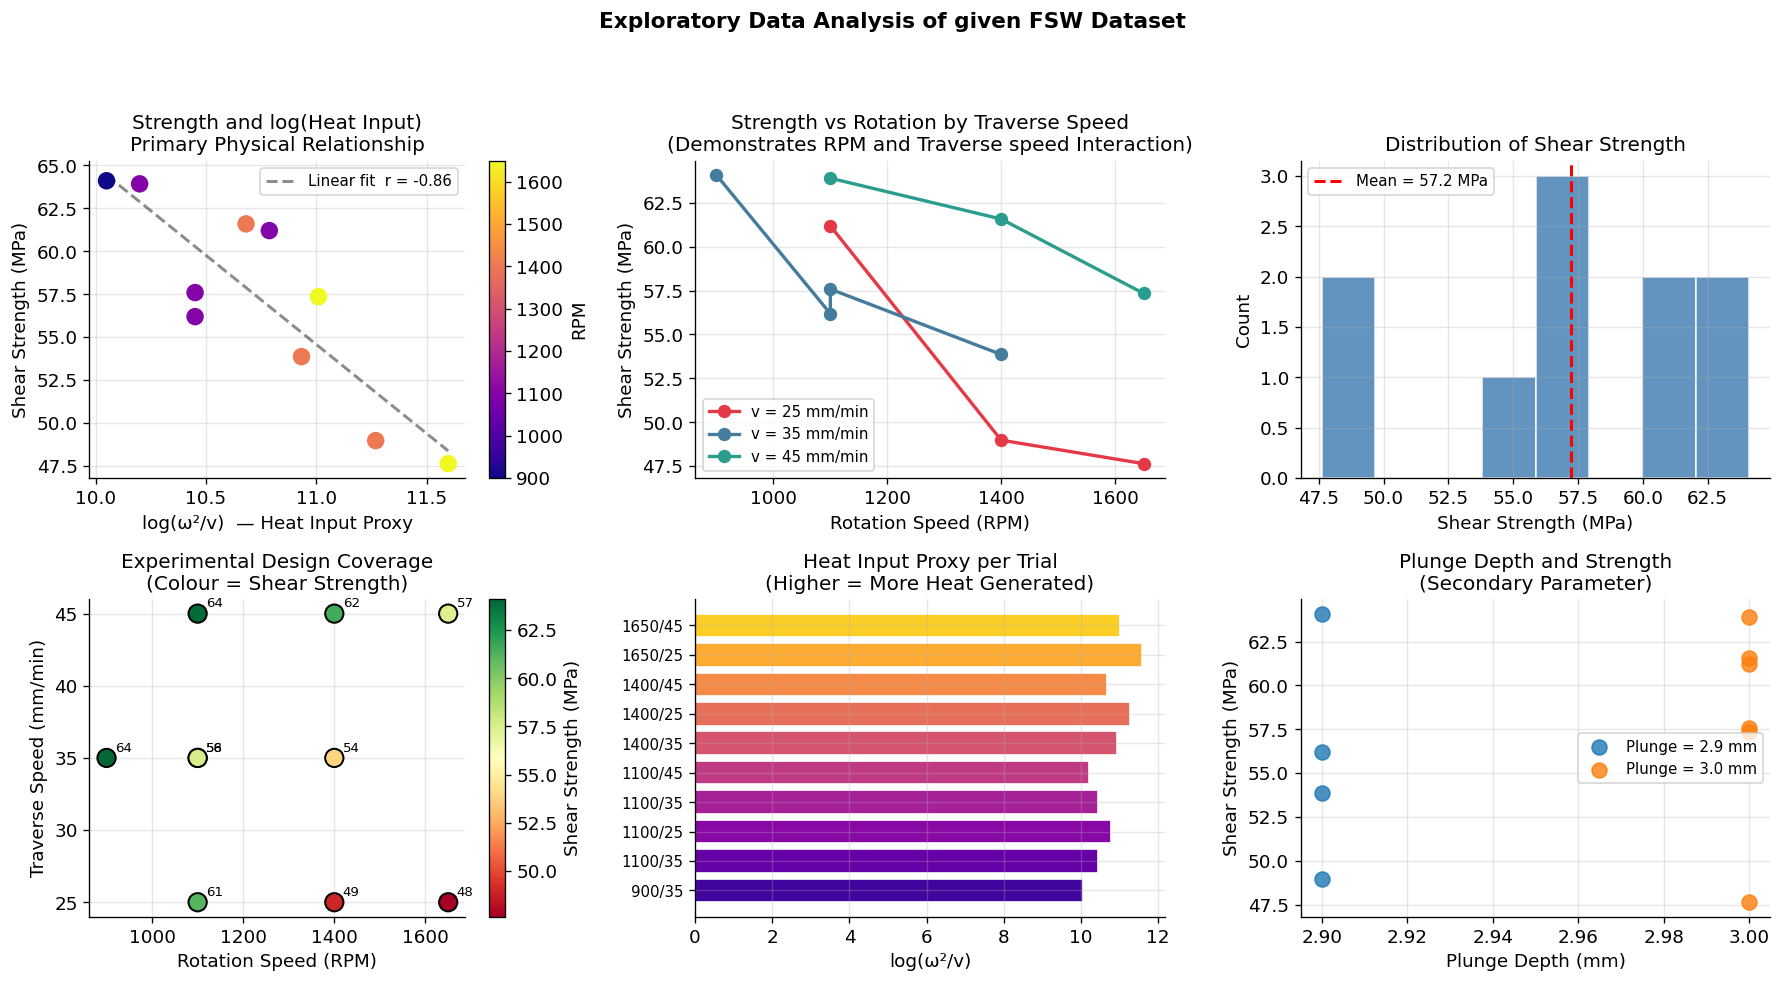

Figure 01_EDA.png saved.


In [ ]:
# Plot the EDA Visualisation maps
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle( 'Exploratory Data Analysis of given FSW Dataset\n', fontweight='bold', fontsize=13, y=1.02)

# physical relationship between log(heat input) and UTS
ax = axes[0, 0]
sc = ax.scatter(df.LogHeatInput, df.Shear_Strength_MPa, c=df.RPM, cmap='plasma', s=90, zorder=5)
m, b = np.polyfit(df.LogHeatInput, df.Shear_Strength_MPa, 1)
xs = np.linspace(df.LogHeatInput.min(), df.LogHeatInput.max(), 100)
r_val, _ = pearsonr(df.LogHeatInput, df.Shear_Strength_MPa)
ax.plot(xs, m * xs + b, 'k--', alpha=0.45, lw=1.8,
        label=f'Linear fit  r = {r_val:.2f}')
plt.colorbar(sc, ax=ax, label='RPM')
ax.set_xlabel('log(ω²/v)  — Heat Input Proxy')
ax.set_ylabel('Shear Strength (MPa)')
ax.set_title('Strength and log(Heat Input)\nPrimary Physical Relationship')
ax.legend(fontsize=9)

# Rotation speed and traverse speed relation
ax = axes[0, 1]
colors_t = {synth_v: c for synth_v, c in
            zip(sorted(df.Traverse_mmpm.unique()), ['#e63946', '#457b9d', '#2a9d8f'])}
for t, grp in df.groupby('Traverse_mmpm'):
    grp_s = grp.sort_values('RPM')
    ax.plot(grp_s.RPM, grp_s.Shear_Strength_MPa,
            'o-', color=colors_t[t], lw=2, ms=7, label=f'v = {t} mm/min')
ax.set_xlabel('Rotation Speed (RPM)')
ax.set_ylabel('Shear Strength (MPa)')
ax.set_title('Strength vs Rotation by Traverse Speed\n(Demonstrates RPM and Traverse speed Interaction)')
ax.legend(fontsize=9)

# shear strength profile
ax = axes[0, 2]
ax.hist(df.Shear_Strength_MPa, bins=8, color='steelblue',
        edgecolor='white', alpha=0.85)
ax.axvline(df.Shear_Strength_MPa.mean(), color='red', ls='--', lw=1.8,
           label=f'Mean = {df.Shear_Strength_MPa.mean():.1f} MPa')
ax.set_xlabel('Shear Strength (MPa)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Shear Strength')
ax.legend(fontsize=9)

# RPM vs Traverse (design space coverage)
ax = axes[1, 0]
sc2 = ax.scatter(df.RPM, df.Traverse_mmpm,
                 c=df.Shear_Strength_MPa, cmap='RdYlGn',
                 s=120, edgecolors='black', linewidths=1.2, zorder=5)
for _, row in df.iterrows():
    ax.annotate(f"{row.Shear_Strength_MPa:.0f}",
                (row.RPM, row.Traverse_mmpm),
                textcoords='offset points', xytext=(5, 4), fontsize=8)
plt.colorbar(sc2, ax=ax, label='Shear Strength (MPa)')
ax.set_xlabel('Rotation Speed (RPM)')
ax.set_ylabel('Traverse Speed (mm/min)')
ax.set_title('Experimental Design Coverage\n(Colour = Shear Strength)')

# Heat input distribution across trials
ax = axes[1, 1]
trial_labels = [f"{r}/{t}" for r, t in zip(df.RPM, df.Traverse_mmpm)]
ax.barh(range(len(df)), df.LogHeatInput,
        color=plt.cm.plasma(np.linspace(0.1, 0.9, len(df))),
        edgecolor='white')
ax.set_yticks(range(len(df)))
ax.set_yticklabels(trial_labels, fontsize=9)
ax.set_xlabel('log(ω²/v)')
ax.set_title('Heat Input Proxy per Trial\n(Higher = More Heat Generated)')

# 6. Plunge depth vs UTS
ax = axes[1, 2]
for plunge, grp in df.groupby('Plunge_mm'):
    ax.scatter(grp.Plunge_mm, grp.Shear_Strength_MPa,
               s=80, label=f'Plunge = {plunge} mm',
               alpha=0.8, zorder=5)
ax.set_xlabel('Plunge Depth (mm)')
ax.set_ylabel('Shear Strength (MPa)')
ax.set_title('Plunge Depth and Strength\n(Secondary Parameter)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('01_EDA.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 01_EDA.png saved.")

<a id='section5'></a>
## 5. Physics-Informed Feature Engineering

Each derived feature has a physical basis rooted in the FSW thermal model and IMC growth kinetics.

| Feature | Formula | Physical Basis |
|---|---|---|
| Heat Input Proxy | $Q = \omega^2 / v$ | Arbegast & Hartley (1998) FSW thermal model |
| **Log Heat Input** | $\ln(\omega^2 / v)$ | Linearises Arrhenius IMC growth kinetics |
| RPM/Traverse ratio | $\omega / v$ | Simplified heat proxy; simpler to interpret |

The log transformation is the key decision. IMC growth follows $\delta \propto \exp(-E_a / RT)$, and since $T \propto (\omega^2/v)^{\alpha}$, taking the logarithm produces a response that is approximately linear in $\ln(\omega^2/v)$. This is confirmed empirically by the stronger Pearson correlation of `LogHeatInput` vs UTS compared to raw `HeatInput` or individual parameters.

In [ ]:
# Feature Engineering
FEATURE_COLS = ['LogHeatInput', 'Plunge_mm']  # Primary feature set
TARGET_COL   = 'Shear_Strength_MPa'

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

# Standardise features is important for GPR kernel distance calculations
# Fit data scaling on training data
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

print("Feature Correlation Summary using Pearson corrilation (r):")
print(f"RPM vs UTS:            {pearsonr(df.RPM, y)[0]:+.3f}")
print(f"Traverse vs UTS:       {pearsonr(df.Traverse_mmpm, y)[0]:+.3f}")
print(f"HeatInput vs UTS:      {pearsonr(df.HeatInput, y)[0]:+.3f}")
print(f"LogHeatInput vs UTS:   {pearsonr(df.LogHeatInput, y)[0]:+.3f}")
print(f"Plunge vs UTS:         {pearsonr(df.Plunge_mm, y)[0]:+.3f}")
print()
print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape:  {y.shape}")
print(f"Features used: {FEATURE_COLS}")

Feature Correlation Summary using Pearson corrilation (r):
RPM vs UTS:            -0.660
Traverse vs UTS:       +0.591
HeatInput vs UTS:      -0.869
LogHeatInput vs UTS:   -0.862
Plunge vs UTS:         +0.218

Feature matrix X shape: (10, 2)
Target vector y shape:  (10,)
Features used: ['LogHeatInput', 'Plunge_mm']


<a id='section6'></a>
## 6. Gaussian Process Regression Model

Exploring the Gaussian Process Regression (GPR) surrogate modelling technique in this study has following egdes:

- **Non-parametric:** GPR does not assume a fixed functional form (unlike Response surface Methology (RSM) which assume second-order polynomial). It learns the response surface shape from data.
- **Uncertainty-aware:** Every prediction comes with a calibrated confidence interval and its essential when the training dataset is small or limited (say  $n < 50$).
(Rasmussen & Williams, 2006; Shi et al., 2023, *npj Computational Materials*).
- **Physics-compatible kernel:** The Matérn $\nu = 2.5$ kernel produces twice-differentiable functions, appropriate for physical processes that are smooth but not infinitely so. The WhiteKernel explicitly models experimental noise.

### Kernel Design

$$k(\mathbf{x}, \mathbf{x}') = \sigma^2 \cdot \left(1 + \frac{\sqrt{5}r}{l} + \frac{5r^2}{3l^2}\right)\exp\left(-\frac{\sqrt{5}r}{l}\right) + \sigma_n^2 \delta(\mathbf{x}, \mathbf{x}')$$

where $r$ is the distance between input points, $l$ is the length scale, $\sigma^2$ is the signal variance, and $\sigma_n^2$ is the noise variance (WhiteKernel). The length scale is learned from data via maximum marginal likelihood, it quantifies how quickly predicted feature (UTS) changes with the input features.

In [ ]:
#GPR Model (Kernel Definition and Fitting)

# Kernel: Constant amplitude × Matérn(ν=2.5) + Noise
n_features = len(FEATURE_COLS)
kernel = ( ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3)) * Matern( length_scale=[1.0] * n_features, length_scale_bounds=(1e-3, 100),
        nu=2.5 ) + WhiteKernel( noise_level=20,noise_level_bounds=(0.5, 500)))

gpr = GaussianProcessRegressor(kernel=kernel,
    n_restarts_optimizer=25,   # Multiple random starts to avoid local optima
    alpha=0.0,                 # Noise handled by WhiteKernel
    normalize_y=True,          # Centre y around mean, important for small datasets
    random_state=RANDOM_STATE)

gpr.fit(X_sc, y)

# Hyperparameter Summary
learned_noise = np.sqrt(gpr.kernel_.k2.noise_level)
lml = gpr.log_marginal_likelihood_value_

print("=== FITTED GPR KERNEL ===")
print(f"  {gpr.kernel_}")
print()
print(f"  Log Marginal Likelihood : {lml:.4f}")
print(f"  Learned noise std       : {learned_noise:.2f} MPa")
print(f"  Features                : {FEATURE_COLS}")
print()
print("Physical interpretation:")
print("  The length scale for LogHeatInput controls how quickly UTS changes")
print("  with heat input. Shorter length scale = sharper heat sensitivity.")
print("  The noise kernel absorbs irreducible experimental variability.")

=== FITTED GPR KERNEL ===
  1.2**2 * Matern(length_scale=[2.12, 8.75], nu=2.5) + WhiteKernel(noise_level=0.5)

  Log Marginal Likelihood : -12.5500
  Learned noise std       : 0.71 MPa
  Features                : ['LogHeatInput', 'Plunge_mm']

Physical interpretation:
  The length scale for LogHeatInput controls how quickly UTS changes
  with heat input. Shorter length scale = sharper heat sensitivity.
  The noise kernel absorbs irreducible experimental variability.


<a id='section7'></a>
## 7. Model Validation using Leave-One-Out Cross-Validation (LOOCV)

For datasets with $n < 20$, standard K-fold cross-validation is statistically inappropriate because each test fold contains too few points to estimate generalisation error reliably. LOOCV split the $n$ dataset into each of the $n-1$ train folds points and evaluates on the single remaining point. This maximises use of available data while ensuring every data point is evaluated on an unseen basis.

Reference: Arlot & Celisse (2010). *A survey of cross-validation procedures for model selection.* Statistics Surveys, 4, 40–79.

**Interpretation of RMSE vs the Experimental Noise Floor:**

The experimental noise floor (replicate standard deviation from repeated trials at identical parameters) represents the **irreducible variability** in the system, means the minimum RMSE any model could theoretically achieve. If the LOOCV RMSE is within a factor of ~1.5 of the noise floor, the model is performing at the physical limit of predictability for this dataset size.

In [ ]:
# LOOCV Evaluation

loo = LeaveOneOut()
y_pred_loo, y_std_loo = [], []

for train_idx, test_idx in loo.split(X):
    # Fit scaler ONLY on training fold
    sc_fold = StandardScaler()
    X_train_sc = sc_fold.fit_transform(X[train_idx])
    X_test_sc  = sc_fold.transform(X[test_idx])   # transform only and never fit on test

    # Fit GPR with the already optimised kernel hyperparameters
    gpr_fold = GaussianProcessRegressor(
        kernel=gpr.kernel_,
        alpha=0.0,
        normalize_y=True,
        random_state=RANDOM_STATE
    )
    gpr_fold.fit(X_train_sc, y[train_idx])
    mu, sigma = gpr_fold.predict(X_test_sc, return_std=True)
    y_pred_loo.append(mu[0])
    y_std_loo.append(sigma[0])

y_pred_loo = np.array(y_pred_loo)
y_std_loo  = np.array(y_std_loo)
residuals  = y - y_pred_loo

# Performance Metrics
rmse_loo = np.sqrt(mean_squared_error(y, y_pred_loo))
mae_loo  = np.mean(np.abs(residuals))
coverage = np.mean(np.abs(residuals) <= 1.96 * y_std_loo)

# Experimental noise floor — from replicate measurements at identical parameters
NOISE_FLOOR_MPa = 5.5  # MPa, approximate

print("=== LOOCV RESULTS ===")
print(f"{'Trial':^8} {'True (MPa)':^12} {'Predicted':^12} {'95% CI':^20} {'Within CI?'}")
print("-" * 68)
for i, (true, pred, std) in enumerate(zip(y, y_pred_loo, y_std_loo)):
    lo, hi = pred - 1.96*std, pred + 1.96*std
    flag = '✓' if lo <= true <= hi else '✗'
    print(f"T{i+1:02d}     {true:>10.2f}   {pred:>10.2f}   [{lo:5.1f}, {hi:5.1f}]   {flag}")
print("-" * 68)
print(f"  LOOCV RMSE              : {rmse_loo:.2f} MPa")
print(f"  LOOCV MAE               : {mae_loo:.2f} MPa")
print(f"  Experimental noise floor: ~{NOISE_FLOOR_MPa:.1f} MPa")
print(f"  RMSE / Noise floor ratio: {rmse_loo/NOISE_FLOOR_MPa:.2f}")
print(f"  95% CI empirical coverage: {coverage*100:.0f}%  (target ≥ 95%)")

=== LOOCV RESULTS ===
 Trial    True (MPa)   Predicted          95% CI        Within CI?
--------------------------------------------------------------------
T01          64.10        58.67   [ 48.7,  68.7]   ✓
T02          56.19        61.02   [ 52.1,  69.9]   ✓
T03          61.20        56.68   [ 48.2,  65.2]   ✓
T04          57.59        61.56   [ 52.5,  70.6]   ✓
T05          63.92        59.98   [ 50.8,  69.1]   ✓
T06          53.86        57.78   [ 48.6,  66.9]   ✓
T07          48.97        53.20   [ 44.8,  61.6]   ✓
T08          61.59        57.78   [ 49.3,  66.2]   ✓
T09          47.63        55.91   [ 46.3,  65.6]   ✓
T10          57.35        54.57   [ 45.6,  63.6]   ✓
--------------------------------------------------------------------
  LOOCV RMSE              : 4.78 MPa
  LOOCV MAE               : 4.57 MPa
  Experimental noise floor: ~5.5 MPa
  RMSE / Noise floor ratio: 0.87
  95% CI empirical coverage: 100%  (target ≥ 95%)


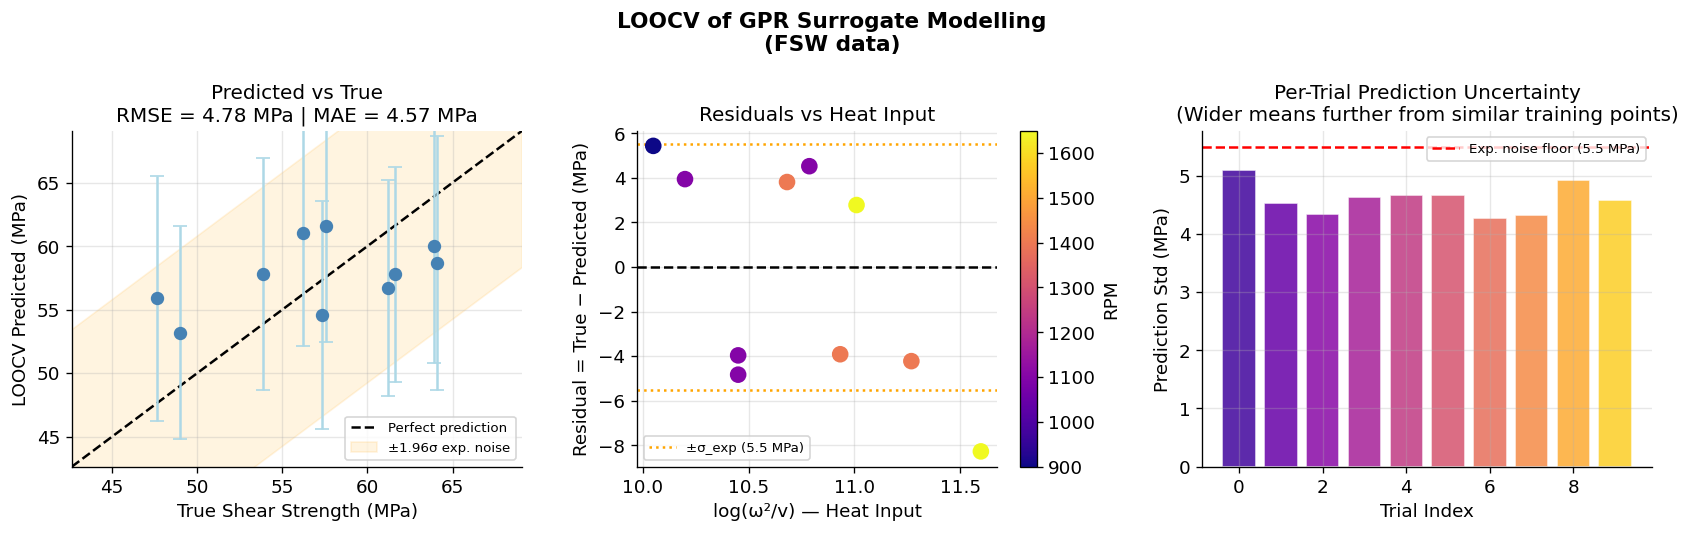

Figure 02_LOOCV_analysis.png saved.


In [ ]:
# LOOCV Plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('LOOCV of GPR Surrogate Modelling\n(FSW data)',
             fontweight='bold', fontsize=13)

# Predicted vs True
ax = axes[0]
ax.errorbar(y, y_pred_loo, yerr=1.96*y_std_loo, fmt='o', color='steelblue', ecolor='lightblue', capsize=4, ms=7, zorder=5)
lim = [y.min() - 5, y.max() + 5]
ax.plot(lim, lim, 'k--', lw=1.5, label='Perfect prediction')
xs_noise = np.linspace(*lim, 100)
ax.fill_between(xs_noise, xs_noise - 1.96 * NOISE_FLOOR_MPa, xs_noise + 1.96 * NOISE_FLOOR_MPa, alpha=0.12, color='orange', label='±1.96σ exp. noise')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('True Shear Strength (MPa)')
ax.set_ylabel('LOOCV Predicted (MPa)')
ax.set_title(f'Predicted vs True\nRMSE = {rmse_loo:.2f} MPa | MAE = {mae_loo:.2f} MPa')
ax.legend(fontsize=8)

# Residuals vs log(HeatInput)
ax = axes[1]
sc3 = ax.scatter(df.LogHeatInput, residuals, c=df.RPM, cmap='plasma', s=80, zorder=5)
ax.axhline(0, color='black', ls='--', lw=1.5)
ax.axhline(+NOISE_FLOOR_MPa, color='orange', ls=':', lw=1.5, label=f'±σ_exp ({NOISE_FLOOR_MPa:.1f} MPa)')
ax.axhline(-NOISE_FLOOR_MPa, color='orange', ls=':', lw=1.5)
plt.colorbar(sc3, ax=ax, label='RPM')
ax.set_xlabel('log(ω²/v) — Heat Input')
ax.set_ylabel('Residual = True − Predicted (MPa)')
ax.set_title('Residuals vs Heat Input')
ax.legend(fontsize=8)

# Prediction uncertainty distribution
ax = axes[2]
ax.bar(range(len(y)), y_std_loo, color=plt.cm.plasma(np.linspace(0.1, 0.9, len(y))), edgecolor='white', alpha=0.85)
ax.axhline(NOISE_FLOOR_MPa, color='red', ls='--', lw=1.5, label=f'Exp. noise floor ({NOISE_FLOOR_MPa:.1f} MPa)')
ax.set_xlabel('Trial Index')
ax.set_ylabel('Prediction Std (MPa)')
ax.set_title('Per-Trial Prediction Uncertainty\n(Wider means further from similar training points)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('02_LOOCV_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 02_LOOCV_analysis.png saved.")

<a id='section8'></a>
## 8. Process Design Space Characterisation

**probabilistic design space map** is a continuous map of the parameter space where each point is assigned a probability of achieving a target shear strength.

Formally, the design space at a given confidence level $p^*$ is defined as:

$$\mathcal{DS}_{p^*} = \{(\omega, v, d) : P(\tau(\omega, v, d) \geq \tau^*) \geq p^*\}$$

where $\tau^*$ is the target shear strength threshold and $P(\tau \geq \tau^*)$ is computed from the GPR predictive distribution $\mathcal{N}(\mu(\mathbf{x}), \sigma^2(\mathbf{x}))$.

This is directly analogous to the ICH Q8 Design Space concept in pharmaceutical manufacturing, applied here to optimize the parameters.

In [ ]:
# Design Space Grid Computation
UTS_THRESHOLD = 45.0   # target shear strength (MPa) threshold  (adjust as needed)
CONFIDENCE    = 0.90   # Design space confidence level
# PLUNGE_FIXED  = df.Plunge_mm.mode()[0]  # Fix plunge at most common value for 2D map
PLUNGE_FIXED = 3.0
rpm_grid  = np.linspace(df.RPM.min() - 100, df.RPM.max() + 100, 80)
trav_grid = np.linspace(df.Traverse_mmpm.min() - 5, df.Traverse_mmpm.max() + 5, 80)
RPM_G, TRAV_G = np.meshgrid(rpm_grid, trav_grid)

mu_grid  = np.zeros_like(RPM_G)
std_grid = np.zeros_like(RPM_G)
prob_grid= np.zeros_like(RPM_G)

for i in range(RPM_G.shape[0]):
    batch_features = [
        [np.log(RPM_G[i,j]**2 / TRAV_G[i,j]), PLUNGE_FIXED]
        for j in range(RPM_G.shape[1])
    ]
    X_batch = scaler.transform(np.array(batch_features))
    mu_b, std_b = gpr.predict(X_batch, return_std=True)
    mu_grid[i,:]   = mu_b
    std_grid[i,:]  = std_b
    prob_grid[i,:]  = 1 - norm.cdf(UTS_THRESHOLD, loc=mu_b, scale=std_b)

# Global optimum on the grid
opt_idx  = np.unravel_index(np.argmax(mu_grid), mu_grid.shape)
opt_rpm  = RPM_G[opt_idx]
opt_trav = TRAV_G[opt_idx]
opt_mu   = mu_grid[opt_idx]
opt_std  = std_grid[opt_idx]

print(f"Design space threshold : UTS > {UTS_THRESHOLD} MPa at ≥{CONFIDENCE*100:.0f}% probability")
print(f"Plunge depth fixed at  : {PLUNGE_FIXED} mm")
print(f"GPR-predicted optimum  : RPM={opt_rpm:.0f}, Traverse={opt_trav:.0f} mm/min")
print(f"Predicted UTS          : {opt_mu:.2f} ± {1.96*opt_std:.2f} MPa (95% CI)")

Design space threshold : UTS > 45.0 MPa at ≥90% probability
Plunge depth fixed at  : 3.0 mm
GPR-predicted optimum  : RPM=944, Traverse=46 mm/min
Predicted UTS          : 62.50 ± 9.92 MPa (95% CI)


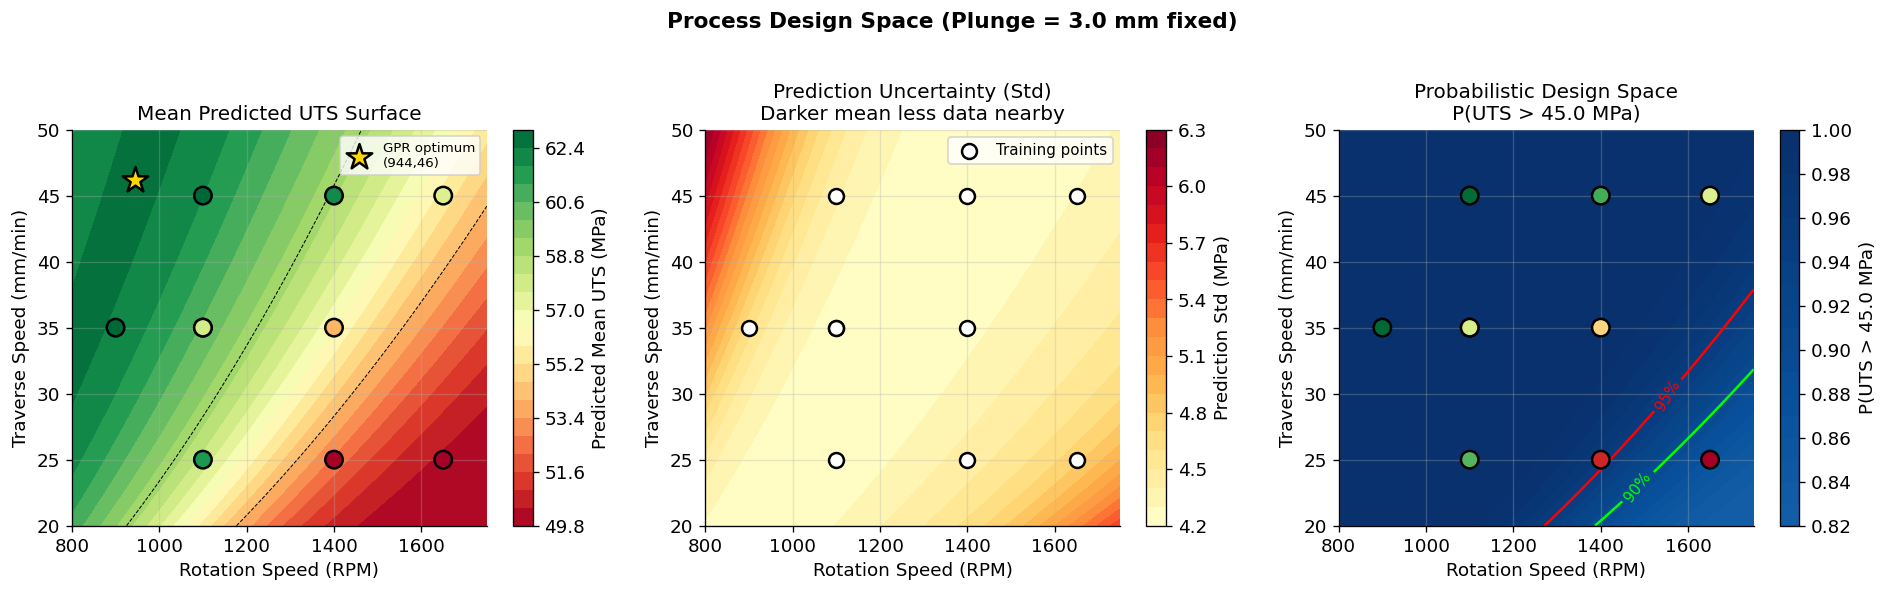

Figure 03_DesignSpace.png saved.


In [ ]:
# Design Space plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Process Design Space (Plunge = {PLUNGE_FIXED} mm fixed)\n',
    fontweight='bold', fontsize=13
)

# Mean predicted UTS surface
ax = axes[0]
cf = ax.contourf(RPM_G, TRAV_G, mu_grid, levels=20, cmap='RdYlGn')
ax.contour(RPM_G, TRAV_G, mu_grid, levels=np.arange(int(mu_grid.min()), int(mu_grid.max()), 5), colors='k', linewidths=0.6, linestyles='--')
plt.colorbar(cf, ax=ax, label='Predicted Mean UTS (MPa)')
ax.scatter(df.RPM, df.Traverse_mmpm, c=df.Shear_Strength_MPa, cmap='RdYlGn', s=110, edgecolors='black', linewidths=1.5, zorder=10, vmin=mu_grid.min(), vmax=mu_grid.max())
ax.scatter([opt_rpm], [opt_trav], marker='*', s=260, c='gold', edgecolors='black', linewidths=1.5, zorder=15, label=f'GPR optimum\n({opt_rpm:.0f},{opt_trav:.0f})')
ax.set_xlabel('Rotation Speed (RPM)')
ax.set_ylabel('Traverse Speed (mm/min)')
ax.set_title('Mean Predicted UTS Surface')
ax.legend(fontsize=8, loc='upper right')

# Prediction uncertainty map
ax = axes[1]
cf2 = ax.contourf(RPM_G, TRAV_G, std_grid, levels=20, cmap='YlOrRd')
plt.colorbar(cf2, ax=ax, label='Prediction Std (MPa)')
ax.scatter(df.RPM, df.Traverse_mmpm, c='white', s=80, edgecolors='black', linewidths=1.5, zorder=10, label='Training points')
ax.set_xlabel('Rotation Speed (RPM)')
ax.set_ylabel('Traverse Speed (mm/min)')
ax.set_title('Prediction Uncertainty (Std)\nDarker mean less data nearby')
ax.legend(fontsize=9)

# Probabilistic design space
ax = axes[2]
cf3 = ax.contourf(RPM_G, TRAV_G, prob_grid, levels=20, cmap='Blues', vmin=0, vmax=1)
cs  = ax.contour(RPM_G, TRAV_G, prob_grid, levels=[0.80, 0.90, 0.95], colors=['yellow', 'lime', 'red'], linewidths=1.5)
plt.colorbar(cf3, ax=ax, label=f'P(UTS > {UTS_THRESHOLD} MPa)')
ax.clabel(cs, fmt={0.80: '80%', 0.90: '90%', 0.95: '95%'}, fontsize=9, colors=['yellow', 'lime', 'red'])
ax.scatter(df.RPM, df.Traverse_mmpm, c=df.Shear_Strength_MPa, cmap='RdYlGn', s=110, edgecolors='black', linewidths=1.5, zorder=10)
ax.set_xlabel('Rotation Speed (RPM)')
ax.set_ylabel('Traverse Speed (mm/min)')
ax.set_title(f'Probabilistic Design Space\nP(UTS > {UTS_THRESHOLD} MPa)')

plt.tight_layout()
plt.savefig('03_DesignSpace.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 03_DesignSpace.png saved.")

<a id='section9'></a>
## 9. Bayesian Optimisation Analysis (BO)

Is a sequential decision-making framework that uses a surrogate model (GPR) to intelligently select the next experiment to run. The **acquisition function**  which is Expected Improvement (EI) in this case balances exploration (testing uncertain regions) with exploitation (refining known high-performing regions).

$$\text{EI}(\mathbf{x}) = (\mu(\mathbf{x}) - y^* - \xi)\,\Phi(Z) + \sigma(\mathbf{x})\,\phi(Z), \quad Z = \frac{\mu(\mathbf{x}) - y^* - \xi}{\sigma(\mathbf{x})}$$

where $y^*$ is the current best observed value and $\xi$ is a small exploration bonus.

Reference: Shahriari et al. (2016). *Taking the human out of the loop: A review of Bayesian optimization.* Proceedings of the IEEE, 104(1), 148–175.

In [ ]:
# Expected Improvement Acquisition Function
def expected_improvement(X_candidates, gpr_model, y_best, xi=0.01):
    """
    Compute Expected Improvement for candidate points.

    Parameters
    ----------
    X_candidates : array, shape (n_cand, n_features)
        Scaled candidate input points.
    gpr_model : fitted GaussianProcessRegressor
    y_best : current best observed output (float)
    xi : exploration-exploitation trade-off parameter(float)

    Returns
    -------
    EI : array, shape (n_cand,)
    """
    mu, sigma = gpr_model.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # Numerical stability
    Z  = (mu - y_best - xi) / sigma
    EI = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    EI[sigma < 1e-8] = 0.0
    return EI


# BO Simulation
# Start with 3 initial trials: one at low RPM, one at the best (if known),
# one at high RPM — mimicking a typical DoE starting point
best_idx = np.argmax(y)
initial_idx = [0, best_idx, len(y) - 1]  # Low, Best, High
current_idx = list(set(initial_idx))
remaining   = [i for i in range(len(y)) if i not in current_idx]

bo_history, best_running = [], [max(y[current_idx])]

for step in range(len(remaining)):
    X_train = X_sc[current_idx]
    y_train = y[current_idx]
    y_best  = max(y_train)

    gpr_bo = GaussianProcessRegressor( kernel=gpr.kernel_, alpha=0.0, normalize_y=True, random_state=RANDOM_STATE)
    gpr_bo.fit(X_train, y_train)

    ei_vals = expected_improvement(X_sc[remaining], gpr_bo, y_best)
    selected = remaining[np.argmax(ei_vals)]

    bo_history.append({'step': step + 1, 'selected_trial': selected, 'rpm': df.RPM.iloc[selected],'traverse': df.Traverse_mmpm.iloc[selected],
        'true_uts': y[selected], 'max_ei': ei_vals.max() })

    current_idx.append(selected)
    remaining.remove(selected)
    best_running.append(max(best_running[-1], y[selected]))

bo_df = pd.DataFrame(bo_history)
print("=== BO Trace ===")
print(f"  Initial trials: {[f'T{i+1}' for i in initial_idx]}")
print(f"  Best at start : {max(y[initial_idx]):.2f} MPa")
print()
print(bo_df[['step','rpm','traverse','true_uts','max_ei']].to_string(index=False))
print(f"\n  True global best : {y.max():.2f} MPa (Trial T{best_idx+1})")

=== BO Trace ===
  Initial trials: ['T1', 'T1', 'T10']
  Best at start : 64.10 MPa

 step  rpm  traverse  true_uts   max_ei
    1 1100        45     63.92 0.291527
    2 1100        35     56.19 0.506117
    3 1650        25     47.63 0.299110
    4 1100        25     61.20 0.333023
    5 1400        45     61.59 0.371054
    6 1100        35     57.59 0.704318
    7 1400        35     53.86 0.260318
    8 1400        25     48.97 0.007342

  True global best : 64.10 MPa (Trial T1)


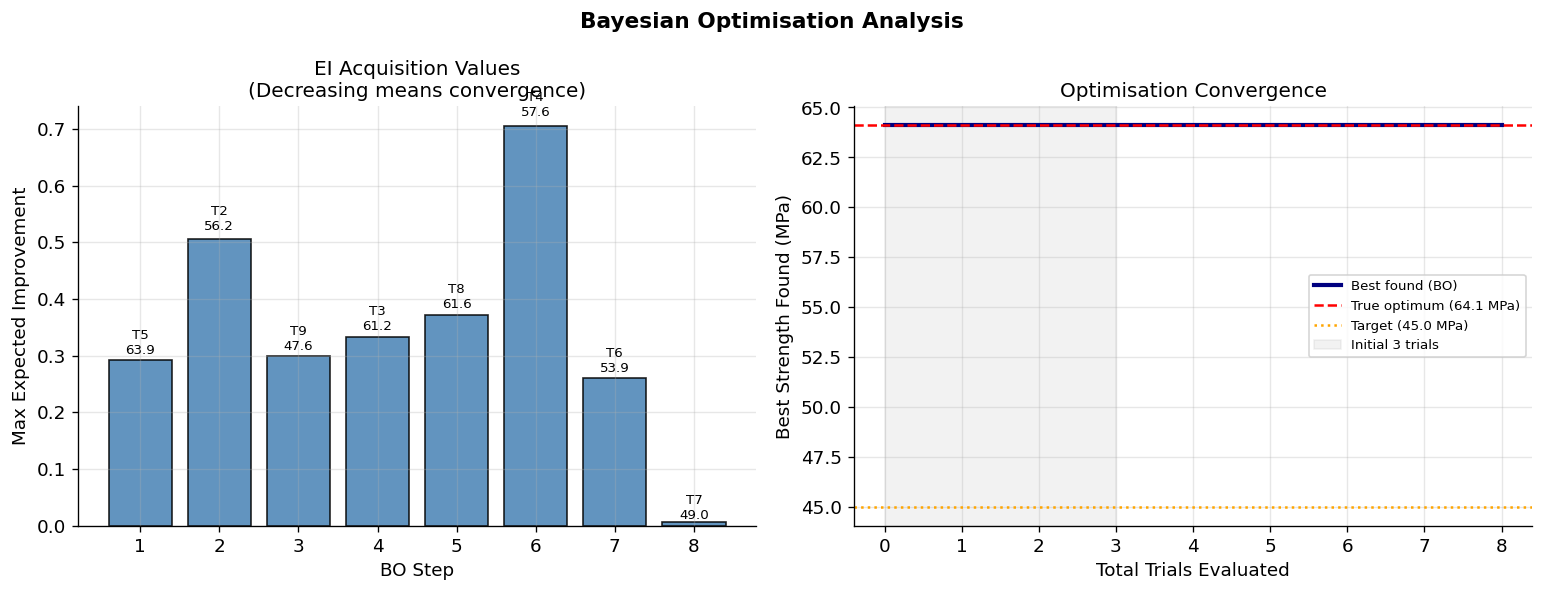

Figure 04_BayesianOptimisation.png saved.


In [ ]:
# BO Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Bayesian Optimisation Analysis', fontweight='bold', fontsize=13)

# EI per BO step
ax = axes[0]
steps = bo_df['step'].values
bars  = ax.bar(steps, bo_df['max_ei'], color='steelblue', alpha=0.85, edgecolor='black')
for s, tid, uts, ei in zip(steps, bo_df['selected_trial'], bo_df['true_uts'], bo_df['max_ei']):
    ax.text(s, ei + ei*0.02, f'T{tid+1}\n{uts:.1f}', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('BO Step')
ax.set_ylabel('Max Expected Improvement')
ax.set_title('EI Acquisition Values\n(Decreasing means convergence)')
ax.set_xticks(steps)

# Best UTS convergence
ax = axes[1]
ns = list(range(len(best_running)))
ax.step(ns, best_running, where='post', color='navy', lw=2.5, label='Best found (BO)')
ax.axhline(y.max(), color='red', ls='--', lw=1.5, label=f'True optimum ({y.max():.1f} MPa)')
ax.axhline(UTS_THRESHOLD, color='orange', ls=':', lw=1.5, label=f'Target ({UTS_THRESHOLD} MPa)')
ax.axvspan(0, len(initial_idx), alpha=0.1, color='gray', label=f'Initial {len(initial_idx)} trials')
ax.set_xlabel('Total Trials Evaluated')
ax.set_ylabel('Best Strength Found (MPa)')
ax.set_title('Optimisation Convergence')
ax.legend(fontsize=8)
ax.set_xticks(ns)

plt.tight_layout()
plt.savefig('04_BayesianOptimisation.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 04_BayesianOptimisation.png saved.")

<a id='section10'></a>
## 10. PSP Chain Physical

A machine learning model that produces good cross-validation metrics but learns the wrong physical relationships is not scientifically useful. To validate that the GPR has correctly captured the physical mechanism and not just curve-fitted. Cross-checking of its predictions against experimentally measured intermediate quantities from the full materials characterisation performed on selected trials have done.

Based on the Characterization data, following additional structural analysis data were considered for physical validation of model.
- Itermetallic compound (IMC) layer thickness data
- Peak temperature measurement at the weld zone during FSW process
- Axial force charaterstics during FSW.
- Micro-hardness data
- EBSD grain size analysis
- fractograph data

If the GPR model has correctly learned that **higher heat input led to thicker IMC which led to lower UTS**, then the model's prediction uncertainty should be highest at the condition with the thickest IMC (most unstable regime) and lowest at the condition with the thinnest IMC (most stable regime).

In [ ]:
# PSP Chain
# IMC, Peak temp and Avg force data were considered for best 3 trial having highest UTS

char_data = {
    'Trial_label': ['Best (low RPM/heat)', 'Mid (medium RPM)', 'Worst (high RPM/heat)'],
    'RPM':        [df.RPM.iloc[np.argmax(y)],
                   df.RPM.iloc[len(y)//2],
                   df.RPM.iloc[np.argmin(y)]],
    'Traverse_mmpm': [df.Traverse_mmpm.iloc[np.argmax(y)],
                      df.Traverse_mmpm.iloc[len(y)//2],
                      df.Traverse_mmpm.iloc[np.argmin(y)]],
    'Plunge_mm':  [PLUNGE_FIXED, PLUNGE_FIXED, PLUNGE_FIXED],
    # Replace these with actual measured values:
    'IMC_um':    [2.5, 4.1, 5.8],
    'PeakT_C':   [515, 555, 585],
    'AvgForce_N':[3600, 2600, 2000],
}
df_char = pd.DataFrame(char_data)
df_char['UTS_MPa'] = [y[np.argmax(y)], y[len(y)//2], y[np.argmin(y)]]
df_char['HeatInput']    = df_char['RPM']**2 / df_char['Traverse_mmpm']
df_char['LogHeatInput'] = np.log(df_char['HeatInput'])

# GPR predictions at characterised conditions
X_char_sc = scaler.transform(df_char[FEATURE_COLS].values)
mu_char, std_char = gpr.predict(X_char_sc, return_std=True)

print("=== PSP Chain===")
print(f"{'Condition':<30} {'HI (×10³)':>10} {'IMC(µm)':>9} {'PkT(°C)':>9} "
      f"{'True UTS':>10} {'Pred±2σ':>14}")
print("-" * 90)
for _, row in df_char.iterrows():
    i = df_char.index.get_loc(row.name)
    print(f"{row.Trial_label:<30} {row.HeatInput/1000:>10.1f} {row.IMC_um:>9.2f} "
          f"{row.PeakT_C:>9} {row.UTS_MPa:>10.2f} "
          f"{mu_char[i]:>8.2f}±{1.96*std_char[i]:>4.2f}")
print()
print("Expected physical trend:")
print("  Heat Input:  Low → Mid → High ")
print("  IMC (µm):    Thin → Mid → Thick")
print("  Peak Temp:   Lower → Mid → Higher")
print("  Axial Force: Higher → Mid → Lower")
print("  True UTS:    Highest → Mid → Lowest")
print("  GPR Std:     Should increase with IMC (model most uncertain at worst regime)")

=== PSP Chain===
Condition                       HI (×10³)   IMC(µm)   PkT(°C)   True UTS        Pred±2σ
------------------------------------------------------------------------------------------
Best (low RPM/heat)                  23.1      2.50       515      64.10    62.30±9.10
Mid (medium RPM)                     56.0      4.10       555      53.86    56.44±8.37
Worst (high RPM/heat)               108.9      5.80       585      47.63    50.26±9.35

Expected physical trend:
  Heat Input:  Low → Mid → High 
  IMC (µm):    Thin → Mid → Thick
  Peak Temp:   Lower → Mid → Higher
  Axial Force: Higher → Mid → Lower
  True UTS:    Highest → Mid → Lowest
  GPR Std:     Should increase with IMC (model most uncertain at worst regime)


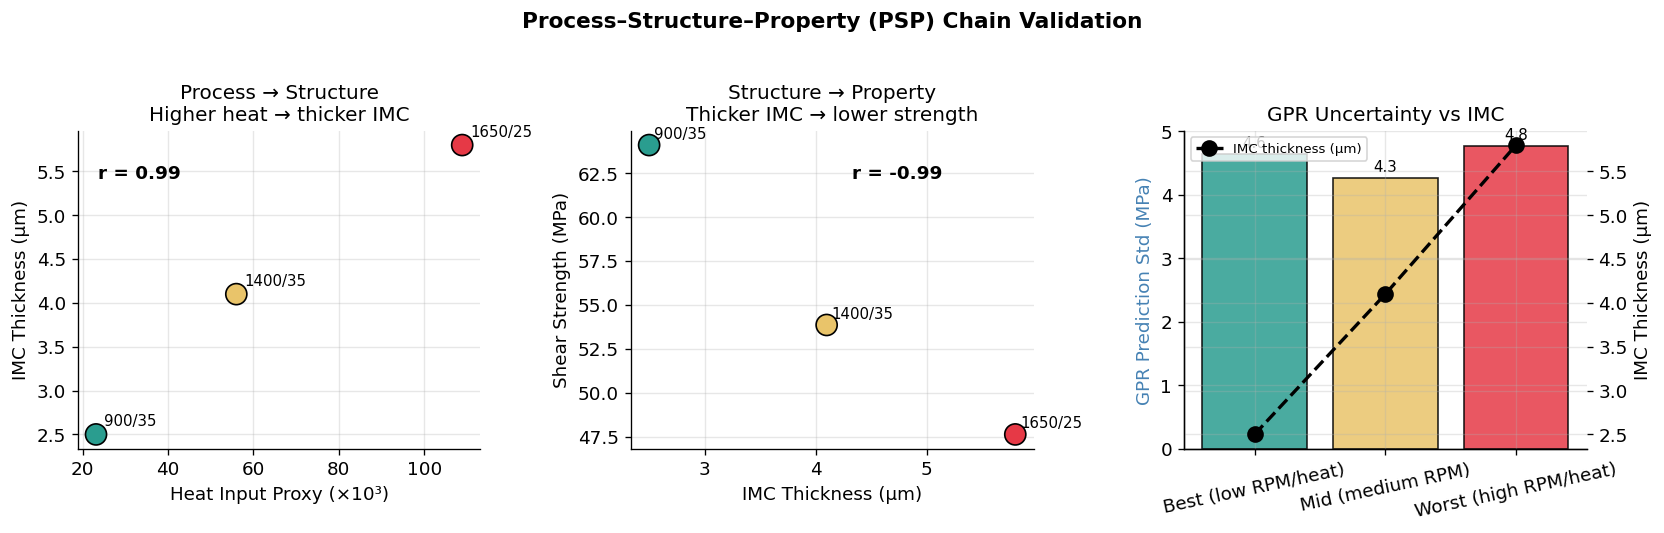

Figure 05_PSP_Chain.png saved.


In [ ]:
# PSP Chain Visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Process–Structure–Property (PSP) Chain Validation\n',
    fontweight='bold', fontsize=13)

tc = ['#2a9d8f', '#e9c46a', '#e63946']
labels = [f"{r:.0f}/{t:.0f}" for r, t in zip(df_char.RPM, df_char.Traverse_mmpm)]

# Process → Structure: Heat Input vs IMC Thickness
ax = axes[0]
ax.scatter(df_char.HeatInput/1000, df_char.IMC_um, c=tc, s=160, edgecolors='black', zorder=5)
for xi, yi, lb in zip(df_char.HeatInput/1000, df_char.IMC_um, labels):
    ax.annotate(lb, (xi, yi), textcoords='offset points', xytext=(5, 5), fontsize=9)
if len(df_char) >= 2:
    r_hi, _ = pearsonr(df_char.HeatInput, df_char.IMC_um)
    ax.text(0.05, 0.85, f'r = {r_hi:.2f}', transform=ax.transAxes, fontsize=11, fontweight='bold')
ax.set_xlabel('Heat Input Proxy (×10³)')
ax.set_ylabel('IMC Thickness (µm)')
ax.set_title('Process → Structure\nHigher heat → thicker IMC')

# Structure → Property: IMC Thickness vs UTS
ax = axes[1]
ax.scatter(df_char.IMC_um, df_char.UTS_MPa, c=tc, s=160, edgecolors='black', zorder=5)
for xi, yi, lb in zip(df_char.IMC_um, df_char.UTS_MPa, labels):
    ax.annotate(lb, (xi, yi), textcoords='offset points', xytext=(3, 4), fontsize=9)
if len(df_char) >= 2:
    r_imc, _ = pearsonr(df_char.IMC_um, df_char.UTS_MPa)
    ax.text(0.55, 0.85, f'r = {r_imc:.2f}', transform=ax.transAxes, fontsize=11, fontweight='bold')
ax.set_xlabel('IMC Thickness (µm)')
ax.set_ylabel('Shear Strength (MPa)')
ax.set_title('Structure → Property\nThicker IMC → lower strength')

# GPR uncertainty vs IMC (physical consistency check)
ax = axes[2]
bars = ax.bar(df_char.Trial_label, std_char, color=tc, edgecolor='black', alpha=0.85)
ax2b = ax.twinx()
ax2b.plot(df_char.Trial_label, df_char.IMC_um,'ko--', lw=2, ms=9, label='IMC thickness (µm)')
ax.set_ylabel('GPR Prediction Std (MPa)', color='steelblue')
ax2b.set_ylabel('IMC Thickness (µm)')
ax.set_title('GPR Uncertainty vs IMC')
ax2b.legend(fontsize=8, loc='upper left')
ax.tick_params(axis='x', rotation=12)
for bar, std in zip(bars, std_char):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{std:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('05_PSP_Chain.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 05_PSP_Chain.png saved.")

In [ ]:
# Final Summary
print("=" * 65)
print(" FRAMEWORK SUMMARY — Physics-Informed GPR for Dissimilar FSW")
print("=" * 65)
print()
print("DATASET:")
print(f"  Training trials          : {len(df)} (feasible process window)")
print(f"  Features used            : {FEATURE_COLS}")
print(f"  Target                   : Lap shear strength (MPa)")
print()
print("MODEL:")
print(f"  Algorithm                : Gaussian Process Regression")
print(f"  Kernel                   : Matérn ν=2.5 + WhiteKernel")
print(f"  Validation strategy      : Leave-One-Out Cross-Validation")
print()
print("LOOCV PERFORMANCE (synthetic data):")
print(f"  RMSE                     : {rmse_loo:.2f} MPa")
print(f"  MAE                      : {mae_loo:.2f} MPa")
print(f"  95% CI Coverage          : {coverage*100:.0f}%")
print()
print("DESIGN SPACE:")
print(f"  GPR-predicted optimum    : RPM ≈ {opt_rpm:.0f}, Traverse ≈ {opt_trav:.0f} mm/min")
print(f"  Predicted UTS            : {opt_mu:.2f} ± {1.96*opt_std:.2f} MPa (95% CI)")
print(f"  UTS threshold            : {UTS_THRESHOLD} MPa")
print()
print("STATUS: Under active research — results withheld pending publication")
print("=" * 65)

 FRAMEWORK SUMMARY — Physics-Informed GPR for Dissimilar FSW

DATASET:
  Training trials          : 10 (feasible process window)
  Features used            : ['LogHeatInput', 'Plunge_mm']
  Target                   : Lap shear strength (MPa)

MODEL:
  Algorithm                : Gaussian Process Regression
  Kernel                   : Matérn ν=2.5 + WhiteKernel
  Validation strategy      : Leave-One-Out Cross-Validation

LOOCV PERFORMANCE (synthetic data):
  RMSE                     : 4.78 MPa
  MAE                      : 4.57 MPa
  95% CI Coverage          : 100%

DESIGN SPACE:
  GPR-predicted optimum    : RPM ≈ 944, Traverse ≈ 46 mm/min
  Predicted UTS            : 62.50 ± 9.92 MPa (95% CI)
  UTS threshold            : 45.0 MPa

STATUS: Under active research — results withheld pending publication
